In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
%matplotlib inline

In [3]:
import pandas as pd 
import numpy as np 
import os
import sys
import itertools
import pickle
import textwrap

from plotly.subplots import make_subplots
import seaborn as sns
from jupyter_dash import JupyterDash
import seaborn as snsH
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy import stats
from scipy import signal
from scipy.fft import fftshift

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import FactorAnalysis
from scipy.linalg import svd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import LeaveOneOut,ShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc #permutation_importance
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import ClusterCentroids



import neptune
import neptune.integrations.sklearn as npt_utils
from neptune.types import File


from collections import Counter
from statistics import mode


from tensorflow import stack
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling1D, BatchNormalization, MaxPool1D, Reshape, Activation
from keras.layers import Conv1D, LSTM
from keras.callbacks import ModelCheckpoint, EarlyStopping


2024-05-01 00:20:55.772744: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
pip install mlxtend


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
sys.path.append('/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_Q2Behave/GitQ2Bheave/q2behave_data_analysis/jupyternotebooks/signal_processing_box')
sys.path.append('/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_Q2Behave/GitQ2Bheave/q2behave_data_analysis/jupyternotebooks/ML_Toolbox/')
from utils_ml import *

from statistical_features import *
from power_spectral_features import *
from filtering_module import *
from helpers import *
from ml_random_forest import *
from ml_svm import *
from gradient_boost import *
from decision_tree import *
from bagging_tree import *

In [6]:
# Read the two feature sets
root_feature_folder = "/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_Q2Behave/CodeOutputs/Windowing_Features/"
df_activity_windowed_psd = pd.read_csv(root_feature_folder + "psd_features_two_second.csv")
df_activity_windowed_stat = pd.read_csv(root_feature_folder+ "stat_features_two_second.csv")
df_activity_windowed =  pd.read_csv(root_feature_folder+  "all_features_two_second.csv")


In [18]:
df_activity_windowed.to_csv("/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_Q2Behave/CodeOutputs/Windowing_Features/sanitized_behavior_codes.csv")

In [8]:
df_activity_windowed = data_clean(df_activity_windowed)
filtered_columns = return_max_signal_features(df_activity_windowed)

['Filtered_Gryo_Max_max_power_psd', 'Filtered_Gryo_Max_min_power_psd', 'Filtered_Gryo_Max_skewness_power_psd', 'Filtered_Gryo_Max_kurtosis_power_psd', 'Filtered_Gryo_Max_mean_power_psd', 'Filtered_Gryo_Max_sum_freq_diff_power_psd', 'Filtered_Gryo_Max_average_power_power_psd', 'Filtered_Gryo_Maxfeature_num_peaks_power_psd', 'Filtered_Acc_Max_max_power_psd', 'Filtered_Acc_Max_min_power_psd', 'Filtered_Acc_Max_skewness_power_psd', 'Filtered_Acc_Max_kurtosis_power_psd', 'Filtered_Acc_Max_mean_power_psd', 'Filtered_Acc_Max_sum_freq_diff_power_psd', 'Filtered_Acc_Max_average_power_power_psd', 'Filtered_Acc_Maxfeature_num_peaks_power_psd', 'Gryo_Max_mean', 'Acc_Max_mean', 'Gryo_Max_median', 'Acc_Max_median', 'Gryo_Max_std', 'Acc_Max_std', 'Gryo_Max_kurtosis', 'Acc_Max_kurtosis', 'Gryo_Max_skewness', 'Acc_Max_skewness', 'Gryo_Max_sum', 'Acc_Max_sum', 'Gryo_Max_zero_cross_rate', 'Acc_Max_zero_cross_rate', 'Gryo_Max_diff_sum', 'Acc_Max_diff_sum']


/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_Q2Behave/GitQ2Bheave/q2behave_data_analysis/jupyternotebooks/ML_Toolbox/bagging_tree.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_activity_windowed_psd["activityID"] = df_activity_windowed_psd["filename"].str.split('_').str[3]
/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_Q2Behave/GitQ2Bheave/q2behave_data_analysis/jupyternotebooks/ML_Toolbox/bagging_tree.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-vers

In [9]:
all_features = [
     "Accel_X_mean",
    "Accel_Y_mean",
    "Accel_Z_mean",
    "Gyro_X_mean",
    "Gyro_Y_mean",
    "Gyro_Z_mean",
    # "Gryo_Max_mean",
    # "Acc_Max_mean",
    "Accel_X_median",
    "Accel_Y_median",
    "Accel_Z_median",
    "Gyro_X_median",
    "Gyro_Y_median",
    "Gyro_Z_median",
    # "Gryo_Max_median",
    # "Acc_Max_median",
    "Accel_X_std",
    "Accel_Y_std",
    "Accel_Z_std",
    "Gyro_X_std",
    "Gyro_Y_std",
    "Gyro_Z_std",
    # "Gryo_Max_std",
    # "Acc_Max_std",
    "Accel_X_kurtosis",
    "Accel_Y_kurtosis",
    "Accel_Z_kurtosis",
    "Gyro_X_kurtosis",
    "Gyro_Y_kurtosis",
    "Gyro_Z_kurtosis",
    # "Gryo_Max_kurtosis",
    # "Acc_Max_kurtosis",
    "Accel_X_skewness",
    "Accel_Y_skewness",
    "Accel_Z_skewness",
    "Gyro_X_skewness",
    "Gyro_Y_skewness",
    "Gyro_Z_skewness",
     "Accel_X_sum",
    "Accel_Y_sum",
    "Accel_Z_sum",
    "Gyro_X_sum",
    "Gyro_Y_sum",
    "Gyro_Z_sum",
    #"Gryo_Max_sum",
    #"Acc_Max_sum",
    "Accel_X_zero_cross_rate",
    "Accel_Y_zero_cross_rate",
    "Accel_Z_zero_cross_rate",
    "Gyro_X_zero_cross_rate",
    "Gyro_Y_zero_cross_rate",
    "Gyro_Z_zero_cross_rate",
    #"Gryo_Max_zero_cross_rate",
    #"Acc_Max_zero_cross_rate",
    "Accel_X_diff_sum",
    "Accel_Y_diff_sum",
    "Accel_Z_diff_sum",
    "Gyro_X_diff_sum",
    "Gyro_Y_diff_sum",
    "Gyro_Z_diff_sum",  
    "Filtered_Accel_X_max_power_psd",
    # "Filtered_Accel_X_min_power_psd",
    "Filtered_Accel_X_skewness_power_psd",
    "Filtered_Accel_X_kurtosis_power_psd",
    "Filtered_Accel_X_mean_power_psd",
    "Filtered_Accel_X_sum_freq_diff_power_psd",
    "Filtered_Accel_X_average_power_power_psd",
    "Filtered_Accel_Xfeature_num_peaks_power_psd",
    "Filtered_Accel_Y_max_power_psd",
    # "Filtered_Accel_Y_min_power_psd",
    "Filtered_Accel_Y_skewness_power_psd",
    "Filtered_Accel_Y_kurtosis_power_psd",
    "Filtered_Accel_Y_mean_power_psd",
    "Filtered_Accel_Y_sum_freq_diff_power_psd",
    "Filtered_Accel_Y_average_power_power_psd",
    "Filtered_Accel_Yfeature_num_peaks_power_psd",
    "Filtered_Accel_Z_max_power_psd",
    # "Filtered_Accel_Z_min_power_psd",
    "Filtered_Accel_Z_skewness_power_psd",
    "Filtered_Accel_Z_kurtosis_power_psd",
    "Filtered_Accel_Z_mean_power_psd",
    "Filtered_Accel_Z_sum_freq_diff_power_psd",
    "Filtered_Accel_Z_average_power_power_psd",
    "Filtered_Accel_Zfeature_num_peaks_power_psd",
    "Filtered_Gryo_X_max_power_psd",
    # "Filtered_Gryo_X_min_power_psd",
    "Filtered_Gryo_X_skewness_power_psd",
    "Filtered_Gryo_X_kurtosis_power_psd",
    "Filtered_Gryo_X_mean_power_psd",
    "Filtered_Gryo_X_sum_freq_diff_power_psd",
    "Filtered_Gryo_X_average_power_power_psd",
    "Filtered_Gryo_Xfeature_num_peaks_power_psd",
    "Filtered_Gryo_Y_max_power_psd",
    "Filtered_Gryo_Y_min_power_psd",
    "Filtered_Gryo_Y_skewness_power_psd",
    "Filtered_Gryo_Y_kurtosis_power_psd",
    "Filtered_Gryo_Y_mean_power_psd",
    "Filtered_Gryo_Y_sum_freq_diff_power_psd",
    "Filtered_Gryo_Y_average_power_power_psd",
    "Filtered_Gryo_Yfeature_num_peaks_power_psd",
    "Filtered_Gryo_Z_max_power_psd",
    # "Filtered_Gryo_Z_min_power_psd",
    "Filtered_Gryo_Z_skewness_power_psd",
    "Filtered_Gryo_Z_kurtosis_power_psd",
    "Filtered_Gryo_Z_mean_power_psd",
    "Filtered_Gryo_Z_sum_freq_diff_power_psd",
    "Filtered_Gryo_Z_average_power_power_psd",
    "Filtered_Gryo_Zfeature_num_peaks_power_psd",'WindowNumber', 'filename', 'participantId', 'activityID', 'type','BehaviorCode', 'FeatureName'
    
]

In [10]:
# ##### Standard statistical features:
variables_statistical = [
    "Accel_X_mean",
    "Accel_Y_mean",
    "Accel_Z_mean",
    "Gyro_X_mean",
    "Gyro_Y_mean",
    "Gyro_Z_mean",
    # "Gryo_Max_mean",
    # "Acc_Max_mean",
    "Accel_X_median",
    "Accel_Y_median",
    "Accel_Z_median",
    "Gyro_X_median",
    "Gyro_Y_median",
    "Gyro_Z_median",
    # "Gryo_Max_median",
    # "Acc_Max_median",
    "Accel_X_std",
    "Accel_Y_std",
    "Accel_Z_std",
    "Gyro_X_std",
    "Gyro_Y_std",
    "Gyro_Z_std",
    # "Gryo_Max_std",
    # "Acc_Max_std",
    "Accel_X_kurtosis",
    "Accel_Y_kurtosis",
    "Accel_Z_kurtosis",
    "Gyro_X_kurtosis",
    "Gyro_Y_kurtosis",
    "Gyro_Z_kurtosis",
    # "Gryo_Max_kurtosis",
    # "Acc_Max_kurtosis",
    "Accel_X_skewness",
    "Accel_Y_skewness",
    "Accel_Z_skewness",
    "Gyro_X_skewness",
    "Gyro_Y_skewness",
    "Gyro_Z_skewness",
    # "Gryo_Max_skewness",
    # "Acc_Max_skewness",
    'WindowNumber', 'filename', 'participantId', 'activityID', 'type','BehaviorCode', 'FeatureName'
]

variables_time_domain = [
    "Accel_X_sum",
    "Accel_Y_sum",
    "Accel_Z_sum",
    "Gyro_X_sum",
    "Gyro_Y_sum",
    "Gyro_Z_sum",
    #"Gryo_Max_sum",
    #"Acc_Max_sum",
    "Accel_X_zero_cross_rate",
    "Accel_Y_zero_cross_rate",
    "Accel_Z_zero_cross_rate",
    "Gyro_X_zero_cross_rate",
    "Gyro_Y_zero_cross_rate",
    "Gyro_Z_zero_cross_rate",
    #"Gryo_Max_zero_cross_rate",
    #"Acc_Max_zero_cross_rate",
    "Accel_X_diff_sum",
    "Accel_Y_diff_sum",
    "Accel_Z_diff_sum",
    "Gyro_X_diff_sum",
    "Gyro_Y_diff_sum",
    "Gyro_Z_diff_sum", 'WindowNumber', 'filename', 'participantId', 'activityID', 'type','BehaviorCode', 'FeatureName'
    #"Gryo_Max_diff_sum",
    #"Acc_Max_diff_sum"
]

In [11]:
variables_frequency_domain = [
    "Filtered_Accel_X_max_power_psd",
    # "Filtered_Accel_X_min_power_psd",
    "Filtered_Accel_X_skewness_power_psd",
    "Filtered_Accel_X_kurtosis_power_psd",
    "Filtered_Accel_X_mean_power_psd",
    "Filtered_Accel_X_sum_freq_diff_power_psd",
    "Filtered_Accel_X_average_power_power_psd",
    "Filtered_Accel_Xfeature_num_peaks_power_psd",
    "Filtered_Accel_Y_max_power_psd",
    # "Filtered_Accel_Y_min_power_psd",
    "Filtered_Accel_Y_skewness_power_psd",
    "Filtered_Accel_Y_kurtosis_power_psd",
    "Filtered_Accel_Y_mean_power_psd",
    "Filtered_Accel_Y_sum_freq_diff_power_psd",
    "Filtered_Accel_Y_average_power_power_psd",
    "Filtered_Accel_Yfeature_num_peaks_power_psd",
    "Filtered_Accel_Z_max_power_psd",
    # "Filtered_Accel_Z_min_power_psd",
    "Filtered_Accel_Z_skewness_power_psd",
    "Filtered_Accel_Z_kurtosis_power_psd",
    "Filtered_Accel_Z_mean_power_psd",
    "Filtered_Accel_Z_sum_freq_diff_power_psd",
    "Filtered_Accel_Z_average_power_power_psd",
    "Filtered_Accel_Zfeature_num_peaks_power_psd",
    "Filtered_Gryo_X_max_power_psd",
    # "Filtered_Gryo_X_min_power_psd",
    "Filtered_Gryo_X_skewness_power_psd",
    "Filtered_Gryo_X_kurtosis_power_psd",
    "Filtered_Gryo_X_mean_power_psd",
    "Filtered_Gryo_X_sum_freq_diff_power_psd",
    "Filtered_Gryo_X_average_power_power_psd",
    "Filtered_Gryo_Xfeature_num_peaks_power_psd",
    "Filtered_Gryo_Y_max_power_psd",
    "Filtered_Gryo_Y_min_power_psd",
    "Filtered_Gryo_Y_skewness_power_psd",
    "Filtered_Gryo_Y_kurtosis_power_psd",
    "Filtered_Gryo_Y_mean_power_psd",
    "Filtered_Gryo_Y_sum_freq_diff_power_psd",
    "Filtered_Gryo_Y_average_power_power_psd",
    "Filtered_Gryo_Yfeature_num_peaks_power_psd",
    "Filtered_Gryo_Z_max_power_psd",
    # "Filtered_Gryo_Z_min_power_psd",
    "Filtered_Gryo_Z_skewness_power_psd",
    "Filtered_Gryo_Z_kurtosis_power_psd",
    "Filtered_Gryo_Z_mean_power_psd",
    "Filtered_Gryo_Z_sum_freq_diff_power_psd",
    "Filtered_Gryo_Z_average_power_power_psd",
    "Filtered_Gryo_Zfeature_num_peaks_power_psd", 'WindowNumber', 'filename', 'participantId', 'activityID', 'type','BehaviorCode', 'FeatureName']

In [12]:
8 +8

16

In [13]:
def activity_segments(df_activity_windowed,feature_list):
    ##################################################################################################################################
    df_activity_windowed_psd_all_act = df_activity_windowed[feature_list]
    df_activity_windowed_psd_A1= df_activity_windowed_psd_all_act[df_activity_windowed_psd_all_act["activityID"]=="A1.csv"]
    df_activity_windowed_psd_A2= df_activity_windowed_psd_all_act[df_activity_windowed_psd_all_act["activityID"]=="A2.csv"]
    df_activity_windowed_psd_A3= df_activity_windowed_psd_all_act[df_activity_windowed_psd_all_act["activityID"]=="A3.csv"]
    df_activity_windowed_psd_A4= df_activity_windowed_psd_all_act[df_activity_windowed_psd_all_act["activityID"]=="A4.csv"]
    df_activity_windowed_psd_all_act = df_activity_windowed_psd_all_act.dropna()
    df_activity_windowed_psd_A1 = df_activity_windowed_psd_A1.dropna()
    df_activity_windowed_psd_A2 = df_activity_windowed_psd_A2.dropna()
    df_activity_windowed_psd_A3 = df_activity_windowed_psd_A3.dropna()
    df_activity_windowed_psd_A4 = df_activity_windowed_psd_A4.dropna()
    return df_activity_windowed_psd_A1,df_activity_windowed_psd_A2,df_activity_windowed_psd_A3,df_activity_windowed_psd_A4,df_activity_windowed_psd_all_act

In [14]:
# Create sanitized labels.
df_activity_windowed = data_clean(df_activity_windowed)
# Filtered out behaviors.
df_activity_windowed = df_activity_windowed[df_activity_windowed['FeatureName'].isin(['NoHyp','TH', 'MO', 'FT', 'DF',"MC"])] #MC ,'MC','SW'
print("New BH code:",df_activity_windowed["BehaviorCode"].unique())
print(df_activity_windowed["FeatureName"].unique())


New BH code: [0 1 4 3 6 5]
['NoHyp' 'MC' 'TH' 'MO' 'FT' 'DF']


In [13]:
df_activity_windowed_psd_A1,df_activity_windowed_psd_A2,df_activity_windowed_psd_A3,df_activity_windowed_psd_A4,df_activity_windowed_psd_all_act = activity_segments(df_activity_windowed,all_features)


In [14]:
df_activity_windowed_psd_all_act.columns


Index(['Accel_X_mean', 'Accel_Y_mean', 'Accel_Z_mean', 'Gyro_X_mean',
       'Gyro_Y_mean', 'Gyro_Z_mean', 'Accel_X_median', 'Accel_Y_median',
       'Accel_Z_median', 'Gyro_X_median', 'Gyro_Y_median', 'Gyro_Z_median',
       'Accel_X_std', 'Accel_Y_std', 'Accel_Z_std', 'Gyro_X_std', 'Gyro_Y_std',
       'Gyro_Z_std', 'Accel_X_kurtosis', 'Accel_Y_kurtosis',
       'Accel_Z_kurtosis', 'Gyro_X_kurtosis', 'Gyro_Y_kurtosis',
       'Gyro_Z_kurtosis', 'Accel_X_skewness', 'Accel_Y_skewness',
       'Accel_Z_skewness', 'Gyro_X_skewness', 'Gyro_Y_skewness',
       'Gyro_Z_skewness', 'Accel_X_sum', 'Accel_Y_sum', 'Accel_Z_sum',
       'Gyro_X_sum', 'Gyro_Y_sum', 'Gyro_Z_sum', 'Accel_X_zero_cross_rate',
       'Accel_Y_zero_cross_rate', 'Accel_Z_zero_cross_rate',
       'Gyro_X_zero_cross_rate', 'Gyro_Y_zero_cross_rate',
       'Gyro_Z_zero_cross_rate', 'Accel_X_diff_sum', 'Accel_Y_diff_sum',
       'Accel_Z_diff_sum', 'Gyro_X_diff_sum', 'Gyro_Y_diff_sum',
       'Gyro_Z_diff_sum', 'Filtered_Acc

In [15]:
df_activity_windowed_psd_A1["FeatureName"].value_counts()

FeatureName
NoHyp    6964
MC        213
MO         70
TH         40
DF         15
Name: count, dtype: int64

In [16]:
df_activity_windowed_psd_A1["type"].value_counts()

type
0    6964
1     338
Name: count, dtype: int64

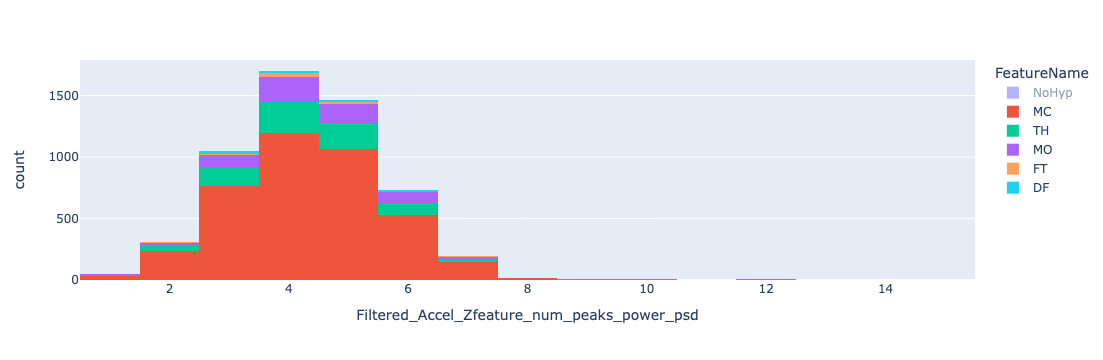

In [33]:
df = px.data.tips()
fig = px.histogram(df_activity_windowed_psd_all_act, x="Filtered_Accel_Zfeature_num_peaks_power_psd", color="FeatureName")
fig.show()

In [22]:
df_activity_windowed_psd_all_act.columns

Index(['Accel_X_mean', 'Accel_Y_mean', 'Accel_Z_mean', 'Gyro_X_mean',
       'Gyro_Y_mean', 'Gyro_Z_mean', 'Accel_X_median', 'Accel_Y_median',
       'Accel_Z_median', 'Gyro_X_median', 'Gyro_Y_median', 'Gyro_Z_median',
       'Accel_X_std', 'Accel_Y_std', 'Accel_Z_std', 'Gyro_X_std', 'Gyro_Y_std',
       'Gyro_Z_std', 'Accel_X_kurtosis', 'Accel_Y_kurtosis',
       'Accel_Z_kurtosis', 'Gyro_X_kurtosis', 'Gyro_Y_kurtosis',
       'Gyro_Z_kurtosis', 'Accel_X_skewness', 'Accel_Y_skewness',
       'Accel_Z_skewness', 'Gyro_X_skewness', 'Gyro_Y_skewness',
       'Gyro_Z_skewness', 'Accel_X_sum', 'Accel_Y_sum', 'Accel_Z_sum',
       'Gyro_X_sum', 'Gyro_Y_sum', 'Gyro_Z_sum', 'Accel_X_zero_cross_rate',
       'Accel_Y_zero_cross_rate', 'Accel_Z_zero_cross_rate',
       'Gyro_X_zero_cross_rate', 'Gyro_Y_zero_cross_rate',
       'Gyro_Z_zero_cross_rate', 'Accel_X_diff_sum', 'Accel_Y_diff_sum',
       'Accel_Z_diff_sum', 'Gyro_X_diff_sum', 'Gyro_Y_diff_sum',
       'Gyro_Z_diff_sum', 'Filtered_Acc

In [28]:
df_activity_windowed_psd_all_act.columns

Index(['Accel_X_mean', 'Accel_Y_mean', 'Accel_Z_mean', 'Gyro_X_mean',
       'Gyro_Y_mean', 'Gyro_Z_mean', 'Accel_X_median', 'Accel_Y_median',
       'Accel_Z_median', 'Gyro_X_median', 'Gyro_Y_median', 'Gyro_Z_median',
       'Accel_X_std', 'Accel_Y_std', 'Accel_Z_std', 'Gyro_X_std', 'Gyro_Y_std',
       'Gyro_Z_std', 'Accel_X_kurtosis', 'Accel_Y_kurtosis',
       'Accel_Z_kurtosis', 'Gyro_X_kurtosis', 'Gyro_Y_kurtosis',
       'Gyro_Z_kurtosis', 'Accel_X_skewness', 'Accel_Y_skewness',
       'Accel_Z_skewness', 'Gyro_X_skewness', 'Gyro_Y_skewness',
       'Gyro_Z_skewness', 'Accel_X_sum', 'Accel_Y_sum', 'Accel_Z_sum',
       'Gyro_X_sum', 'Gyro_Y_sum', 'Gyro_Z_sum', 'Accel_X_zero_cross_rate',
       'Accel_Y_zero_cross_rate', 'Accel_Z_zero_cross_rate',
       'Gyro_X_zero_cross_rate', 'Gyro_Y_zero_cross_rate',
       'Gyro_Z_zero_cross_rate', 'Accel_X_diff_sum', 'Accel_Y_diff_sum',
       'Accel_Z_diff_sum', 'Gyro_X_diff_sum', 'Gyro_Y_diff_sum',
       'Gyro_Z_diff_sum', 'Filtered_Acc

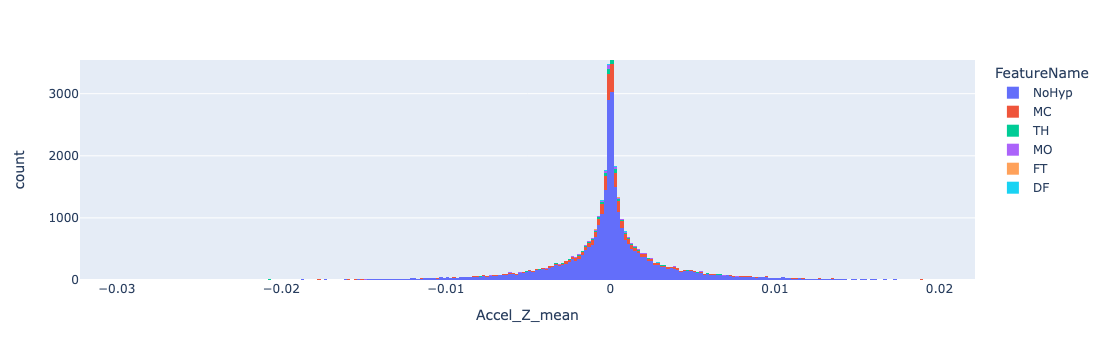

In [32]:
df = px.data.tips()
fig = px.histogram(df_activity_windowed_psd_all_act, x="Accel_Z_mean", color="FeatureName")
fig.show()

Number of Peaks PSD


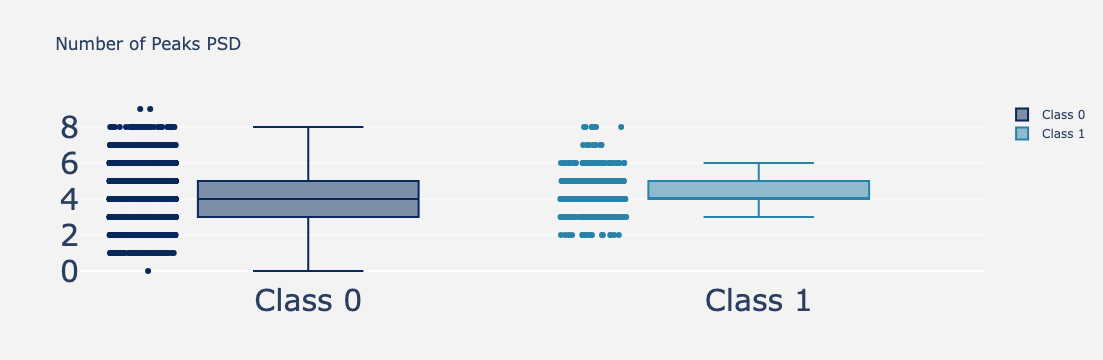

In [39]:
print("Number of Peaks PSD")
fig = go.Figure()
fig.add_trace(go.Box(y=df_activity_windowed_psd_A1[df_activity_windowed_psd_A1["type"]==0]['Filtered_Accel_Xfeature_num_peaks_power_psd']  , boxpoints='all', name="Class 0",    marker_color='rgb(7,40,89)', hovertemplate='%{y:.4f}'))
fig.add_trace(go.Box(y=df_activity_windowed_psd_A1[df_activity_windowed_psd_A1["type"]==1]['Filtered_Accel_Xfeature_num_peaks_power_psd']  , boxpoints='all',name="Class 1",    marker_color='rgb(42, 130, 168)',  hovertemplate='%{y:.4f}'))
# fig.add_trace(go.Box(y=df_activity_windowed_psd_A1[df_activity_windowed_psd_A1["FeatureName"]=="DF"]['Filtered_Accel_Xfeature_num_peaks_power_psd'], boxpoints='all',name="DF",    marker_color='rgb(107,174,214)', hovertemplate='%{y:.4f}' ))
# fig.add_trace(go.Box(y=df_activity_windowed_psd_A1[df_activity_windowed_psd_A1["FeatureName"]=="NoHyp"]['Filtered_Accel_Xfeature_num_peaks_power_psd'], boxpoints='all',name="NoHyp",marker_color='rgb(42, 86, 168)',hovertemplate='%{y:.4f}'))
fig.update_layout(
    title="Number of Peaks PSD",
    paper_bgcolor='rgb(243, 243, 243)',
    plot_bgcolor='rgb(243, 243, 243)',
    showlegend=True,
    yaxis = dict(
tickfont = dict(size=30)),
    xaxis = dict(
tickfont = dict(size=30))

)

fig.show()


Maximum Power in PSD


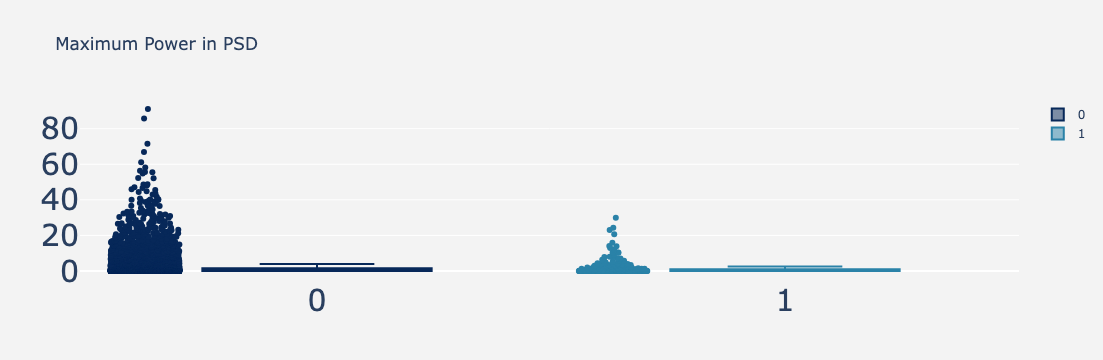

In [41]:
print("Maximum Power in PSD")
fig = go.Figure()
fig.add_trace(go.Box(y=df_activity_windowed_psd_A1[df_activity_windowed_psd_A1["type"]==0]['Filtered_Accel_X_max_power_psd']  , boxpoints='all', name="0",    marker_color='rgb(7,40,89)', hovertemplate='%{y:.4f}'))
fig.add_trace(go.Box(y=df_activity_windowed_psd_A1[df_activity_windowed_psd_A1["type"]==1]['Filtered_Accel_X_max_power_psd']  , boxpoints='all',name="1",    marker_color='rgb(42, 130, 168)',  hovertemplate='%{y:.4f}'))
# fig.add_trace(go.Box(y=df_activity_windowed_psd_A1[df_activity_windowed_psd_A1["FeatureName"]=="DF"]['Filtered_Accel_X_max_power_psd'], boxpoints='all',name="DF",    marker_color='rgb(107,174,214)', hovertemplate='%{y:.4f}' ))
# fig.add_trace(go.Box(y=df_activity_windowed_psd_A1[df_activity_windowed_psd_A1["FeatureName"]=="NoHyp"]['Filtered_Accel_X_max_power_psd'], boxpoints='all',name="NoHyp",marker_color='rgb(42, 86, 168)',hovertemplate='%{y:.4f}'))
fig.update_layout(
    title="Maximum Power in PSD",
    paper_bgcolor='rgb(243, 243, 243)',
    plot_bgcolor='rgb(243, 243, 243)',
    showlegend=True,
    yaxis = dict(
tickfont = dict(size=30)),
    xaxis = dict(
tickfont = dict(size=30))

)

fig.show()


In [16]:
test_set_size = 0.2
undersampling_method  = "Clus" # Rus Clus

## Overall Model Validation

my_train_test_split() ================================ Clustering Centroids


/usr/local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Resampled Number of values in each class:  [(0, 5543), (1, 5543)]
my_train_test_split()/: X_train:  (11086, 91) y_train: (11086,) Value counts in train: <class 'pandas.core.series.Series'> type
0    5543
1    5543
Name: count, dtype: int64
my_train_test_split()/: X_test:  (2218, 91) y_test:   (2218,) Value counts in test: <class 'pandas.core.series.Series'> type
1    1109
0    1109
Name: count, dtype: int64
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1139
X_train_fold:  (5543, 91) y_train_fold:  (5543,)
TP:  2179 TN:  2377 FP:  395 FN:  592
sensitivity:  0.7863587152652473 specificity:  0.8575036075036075
X_train_fold:  (5543, 91) y_train_fold:  (5543,)
TP:  2222 TN:  2345 FP:  426 FN:  550
sensitivity:  0.8015873015873016 specificity:  0.8462648863226272
Average expected loss--After pruning: 0.286
Average bias--After pruning: 0.168
Average variance--After pruning: 0.221
Sklearn 0-1 loss--After pruning: 0.246


/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without

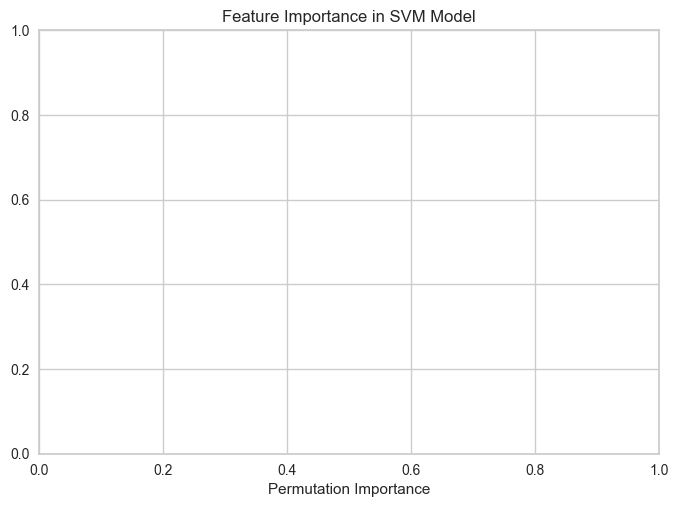

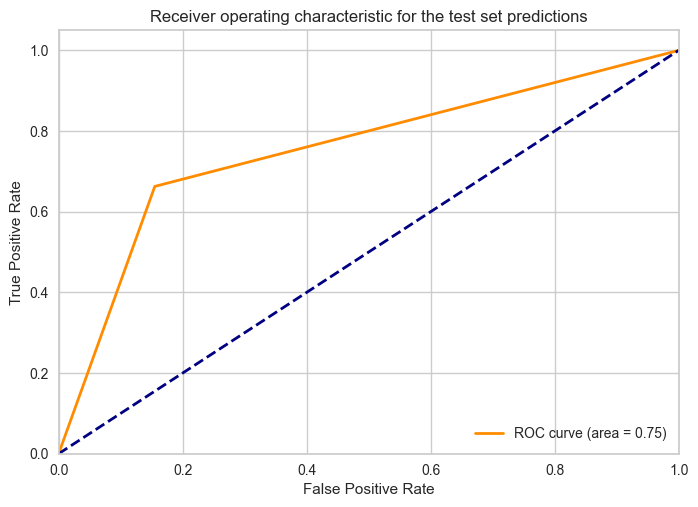

https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1140
X_train_fold:  (8868, 91) y_train_fold:  (8868,)
TP:  856 TN:  1006 FP:  103 FN:  253
sensitivity:  0.7718665464382326 specificity:  0.9071235347159603
X_train_fold:  (8869, 91) y_train_fold:  (8869,)
TP:  857 TN:  992 FP:  117 FN:  251
sensitivity:  0.7734657039711191 specificity:  0.8944995491433724
X_train_fold:  (8869, 91) y_train_fold:  (8869,)
TP:  871 TN:  1005 FP:  104 FN:  237
sensitivity:  0.7861010830324909 specificity:  0.9062218214607755
X_train_fold:  (8869, 91) y_train_fold:  (8869,)
TP:  879 TN:  982 FP:  126 FN:  230
sensitivity:  0.7926059513074842 specificity:  0.8862815884476535
X_train_fold:  (8869, 91) y_train_fold:  (8869,)
TP:  876 TN:  987 FP:  121 FN:  233
sensitivity:  0.7899008115419297 specificity:  0.8907942238267148
Average expected loss--After pruning: 0.286
Average bias--After pruning: 0.168
Average variance--After pruning: 0.221
Sklearn 0-1 loss--After pruning: 0.246


/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without

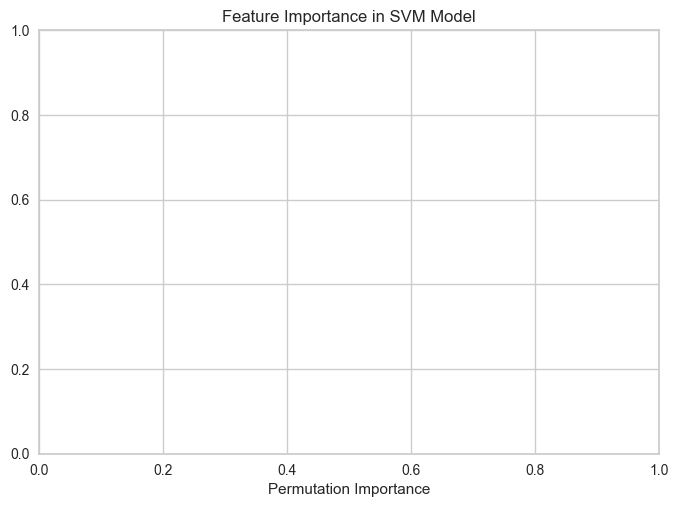

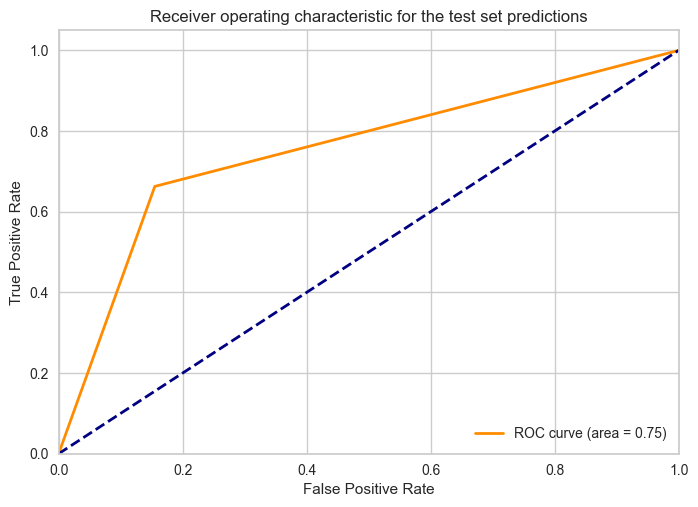

In [20]:
DT_all_act = dt_cross_validation_with_cm(df_activity_windowed_psd_all_act, test_set_size,pid="none",tag=undersampling_method)

In [ ]:
GB_all_act = gb_cross_validation_with_cm(df_activity_windowed_psd_all_act, test_set_size,pid="none",tag=undersampling_method)

my_train_test_split() ================================ Clustering Centroids


/usr/local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Resampled Number of values in each class:  [(0, 5543), (1, 5543)]
my_train_test_split()/: X_train:  (11086, 91) y_train: (11086,) Value counts in train: <class 'pandas.core.series.Series'> type
0    5543
1    5543
Name: count, dtype: int64
my_train_test_split()/: X_test:  (2218, 91) y_test:   (2218,) Value counts in test: <class 'pandas.core.series.Series'> type
0    1109
1    1109
Name: count, dtype: int64
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1141
X_train_fold:  (5543, 91) y_train_fold:  (5543,)
TP:  2267 TN:  2641 FP:  131 FN:  504
sensitivity:  0.8181162035366294 specificity:  0.9527417027417028
X_train_fold:  (5543, 91) y_train_fold:  (5543,)
TP:  2331 TN:  2629 FP:  142 FN:  441
sensitivity:  0.8409090909090909 specificity:  0.9487549621075424


In [ ]:
conf_matrix_rf =  rf_cross_validation_with_cm(df_activity_windowed_psd_all_act, test_set_size,pid="none",tag=undersampling_method)

In [ ]:
bagging_tree(df_activity_windowed_psd_all_act, test_set_size,pid="none",tag=undersampling_method)

### Activity wise validation 

my_train_test_split() ================================ Clustering Centroids


/usr/local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Resampled Number of values in each class:  [(0, 338), (1, 338)]
my_train_test_split()/: X_train:  (676, 40) y_train: (676,) Value counts in train: <class 'pandas.core.series.Series'> type
0    338
1    338
Name: count, dtype: int64
my_train_test_split()/: X_test:  (136, 40) y_test:   (136,) Value counts in test: <class 'pandas.core.series.Series'> type
1    68
0    68
Name: count, dtype: int64
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1113
y_pred_probs: 
 [[0.33461366 0.66538634]
 [0.69361047 0.30638953]
 [0.14701623 0.85298377]
 [0.13781054 0.86218946]
 [0.39128865 0.60871135]
 [0.36858765 0.63141235]
 [0.75852428 0.24147572]
 [0.2853492  0.7146508 ]
 [0.18276651 0.81723349]
 [0.18704145 0.81295855]
 [0.21065848 0.78934152]
 [0.13976727 0.86023273]
 [0.52203595 0.47796405]
 [0.38481802 0.61518198]
 [0.14347686 0.85652314]
 [0.22596985 0.77403015]
 [0.17279193 0.82720807]
 [0.15966145 0.84033855]
 [0.21124989 0.78875011]
 [0.45089834 0.54910166]
 [0.52555038 0.47444962]
 [0.17536672

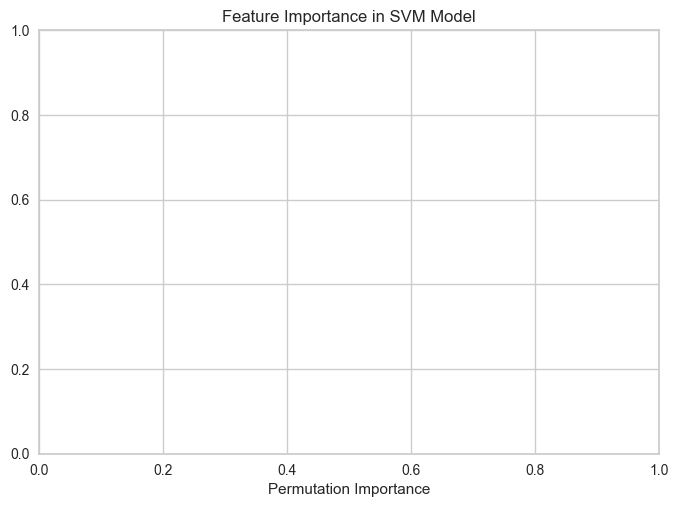

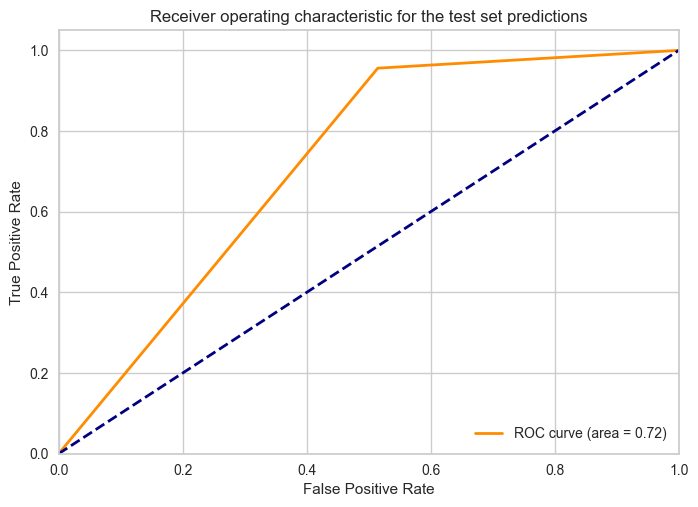

precision:  0.7833333333333333 recall:  0.7205882352941176 f1_score 0.7042124542124543
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1114
y_pred_probs: 
 [[0.35415608 0.64584392]
 [0.70804497 0.29195503]
 [0.14870238 0.85129762]
 [0.2042672  0.7957328 ]
 [0.44807143 0.55192857]
 [0.38071164 0.61928836]
 [0.78061508 0.21938492]
 [0.31350794 0.68649206]
 [0.22331746 0.77668254]
 [0.20790476 0.79209524]
 [0.26570767 0.73429233]
 [0.20077778 0.79922222]
 [0.55348701 0.44651299]
 [0.41097354 0.58902646]
 [0.11657937 0.88342063]
 [0.19356349 0.80643651]
 [0.19874339 0.80125661]
 [0.1505     0.8495    ]
 [0.24043386 0.75956614]
 [0.50086905 0.49913095]
 [0.61389683 0.38610317]
 [0.17909524 0.82090476]
 [0.74214947 0.25785053]
 [0.54218651 0.45781349]
 [0.66331746 0.33668254]
 [0.70564286 0.29435714]
 [0.62773413 0.37226587]
 [0.30750794 0.69249206]
 [0.70792063 0.29207937]
 [0.34099206 0.65900794]
 [0.21905291 0.78094709]
 [0.5767619  0.4232381 ]
 [0.21217593 0.78782407]
 [0.73451852 0.2654814

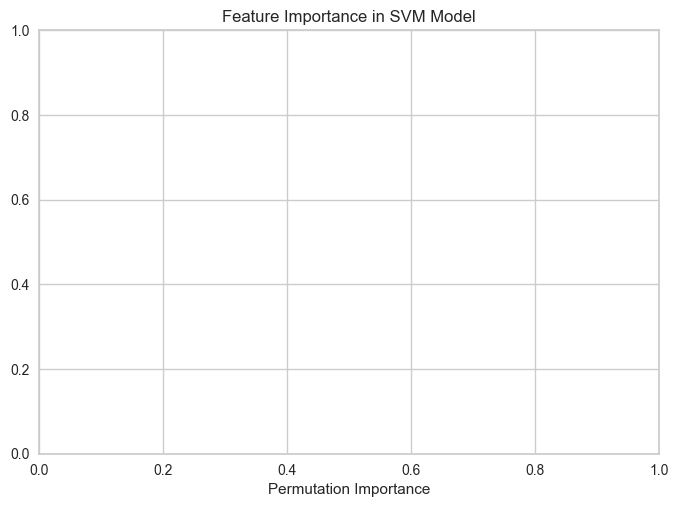

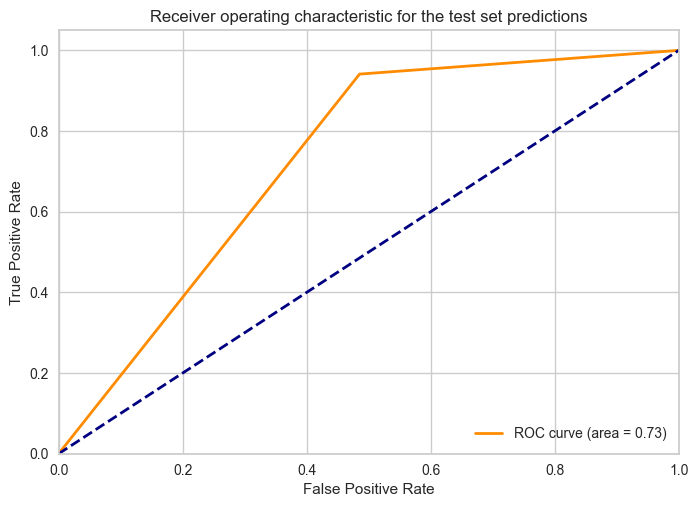

precision:  0.7786148559344436 recall:  0.7279411764705882 f1_score 0.7149815916171056


In [75]:
RF_A1_OR_PSD_Wind =  rf_cross_validation_with_cm(df_activity_windowed_psd_A1, test_set_size,pid="none",tag=undersampling_method)

my_train_test_split() ================================ Clustering Centroids


/usr/local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Resampled Number of values in each class:  [(0, 911), (1, 911)]
my_train_test_split()/: X_train:  (1822, 40) y_train: (1822,) Value counts in train: <class 'pandas.core.series.Series'> type
0    911
1    911
Name: count, dtype: int64
my_train_test_split()/: X_test:  (365, 40) y_test:   (365,) Value counts in test: <class 'pandas.core.series.Series'> type
0    183
1    182
Name: count, dtype: int64
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1115
y_pred_probs: 
 [[0.07433333 0.92566667]
 [0.12669444 0.87330556]
 [0.54644444 0.45355556]
 [0.13704762 0.86295238]
 [0.59435516 0.40564484]
 [0.64297421 0.35702579]
 [0.48634921 0.51365079]
 [0.5819504  0.4180496 ]
 [0.29008333 0.70991667]
 [0.45443254 0.54556746]
 [0.3705119  0.6294881 ]
 [0.20933333 0.79066667]
 [0.56584921 0.43415079]
 [0.40354185 0.59645815]
 [0.54077381 0.45922619]
 [0.31570833 0.68429167]
 [0.55030952 0.44969048]
 [0.42265873 0.57734127]
 [0.34904762 0.65095238]
 [0.61448214 0.38551786]
 [0.41472619 0.58527381]
 [0.1077

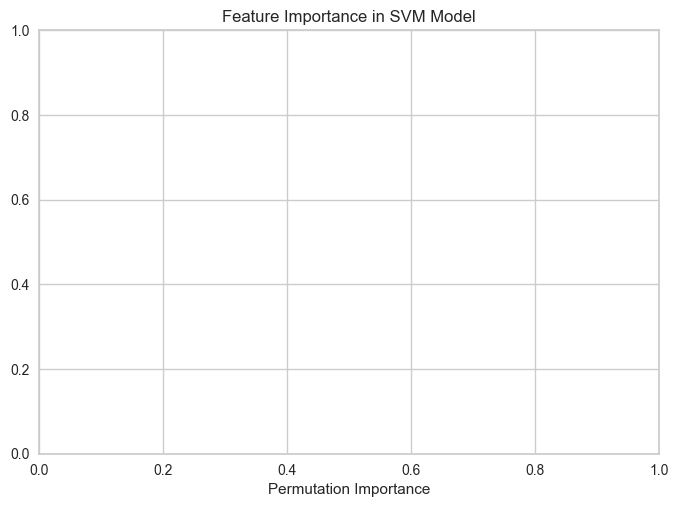

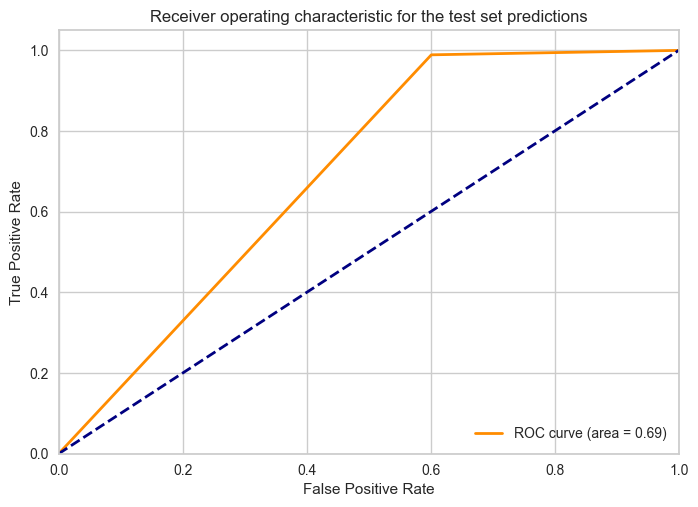

precision:  0.7974945677846008 recall:  0.6931506849315069 f1_score 0.6640320516627881
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1116
y_pred_probs: 
 [[0.07       0.93      ]
 [0.17       0.83      ]
 [0.61       0.39      ]
 [0.17       0.83      ]
 [0.62       0.38      ]
 [0.61666667 0.38333333]
 [0.435      0.565     ]
 [0.56       0.44      ]
 [0.30333333 0.69666667]
 [0.4        0.6       ]
 [0.26       0.74      ]
 [0.25       0.75      ]
 [0.42       0.58      ]
 [0.36       0.64      ]
 [0.56833333 0.43166667]
 [0.33       0.67      ]
 [0.49       0.51      ]
 [0.38       0.62      ]
 [0.28       0.72      ]
 [0.605      0.395     ]
 [0.42333333 0.57666667]
 [0.06       0.94      ]
 [0.29       0.71      ]
 [0.32       0.68      ]
 [0.43583333 0.56416667]
 [0.3        0.7       ]
 [0.39       0.61      ]
 [0.26       0.74      ]
 [0.16       0.84      ]
 [0.34       0.66      ]
 [0.21333333 0.78666667]
 [0.33       0.67      ]
 [0.47       0.53      ]
 [0.37       0.63     

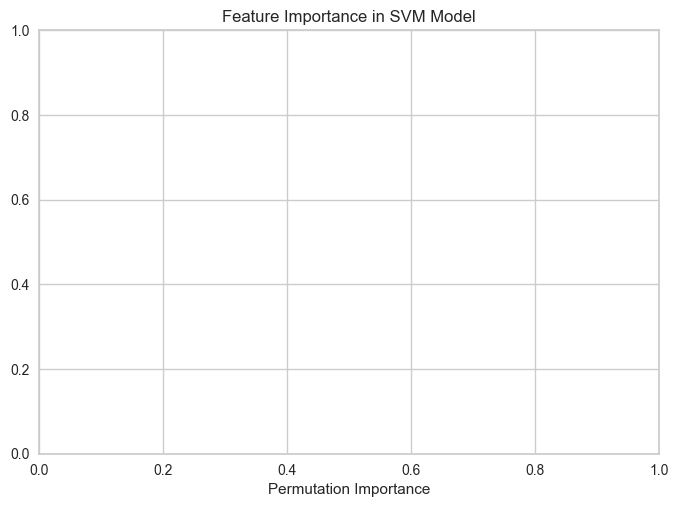

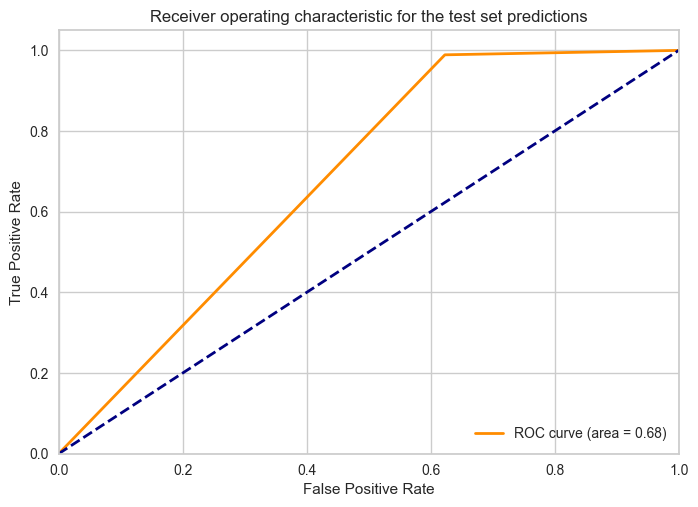

precision:  0.7925305256194703 recall:  0.6821917808219178 f1_score 0.649513029243625


In [76]:
RF_A2_OR_PSD_Wind =  rf_cross_validation_with_cm(df_activity_windowed_psd_A2,test_set_size,pid = "None",tag=undersampling_method) 

my_train_test_split() ================================ Clustering Centroids


/usr/local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Resampled Number of values in each class:  [(0, 3410), (1, 3410)]
my_train_test_split()/: X_train:  (6820, 40) y_train: (6820,) Value counts in train: <class 'pandas.core.series.Series'> type
0    3410
1    3410
Name: count, dtype: int64
my_train_test_split()/: X_test:  (1364, 40) y_test:   (1364,) Value counts in test: <class 'pandas.core.series.Series'> type
1    682
0    682
Name: count, dtype: int64
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1117
y_pred_probs: 
 [[0.57420055 0.42579945]
 [0.37537293 0.62462707]
 [0.35640653 0.64359347]
 ...
 [0.29239546 0.70760454]
 [0.45832987 0.54167013]
 [0.47807365 0.52192635]]
dataset pred probs: 
         Prob_0    Prob_1
0     0.574201  0.425799
1     0.375373  0.624627
2     0.356407  0.643593
3     0.518771  0.481229
4     0.344980  0.655020
...        ...       ...
1359  0.500557  0.499443
1360  0.365118  0.634882
1361  0.292395  0.707605
1362  0.458330  0.541670
1363  0.478074  0.521926

[1364 rows x 2 columns]
X_train_fold:  (3410, 40

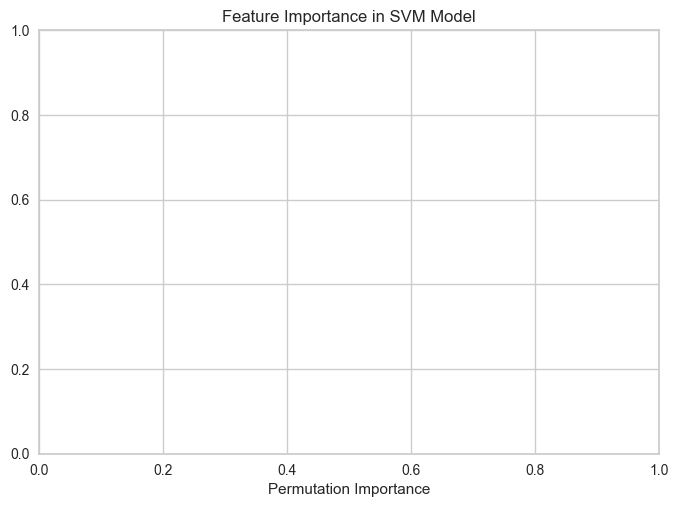

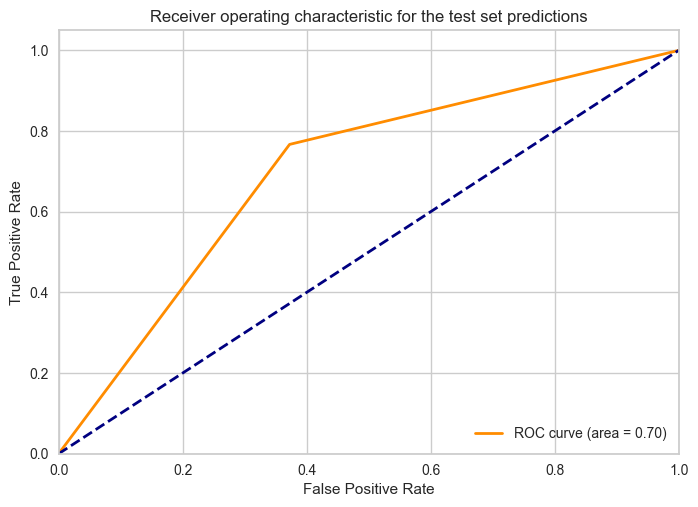

precision:  0.7011164242850784 recall:  0.6972140762463344 f1_score 0.695738145507005
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1118
y_pred_probs: 
 [[0.64321032 0.35678968]
 [0.34746429 0.65253571]
 [0.32963095 0.67036905]
 ...
 [0.32227381 0.67772619]
 [0.53412698 0.46587302]
 [0.49855952 0.50144048]]
dataset pred probs: 
         Prob_0    Prob_1
0     0.643210  0.356790
1     0.347464  0.652536
2     0.329631  0.670369
3     0.544520  0.455480
4     0.312548  0.687452
...        ...       ...
1359  0.526139  0.473861
1360  0.368423  0.631577
1361  0.322274  0.677726
1362  0.534127  0.465873
1363  0.498560  0.501440

[1364 rows x 2 columns]
X_train_fold:  (4546, 40) y_train_fold:  (4546,)
TP:  769 TN:  906 FP:  231 FN:  368
sensitivity:  0.6763412489006156 specificity:  0.7968337730870713
X_train_fold:  (4547, 40) y_train_fold:  (4547,)
TP:  817 TN:  889 FP:  248 FN:  319
sensitivity:  0.7191901408450704 specificity:  0.781882145998241
X_train_fold:  (4547, 40) y_train_fold:  (45

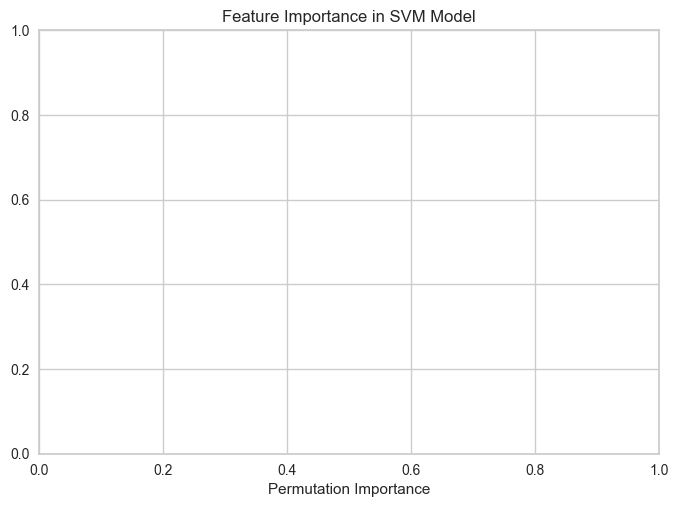

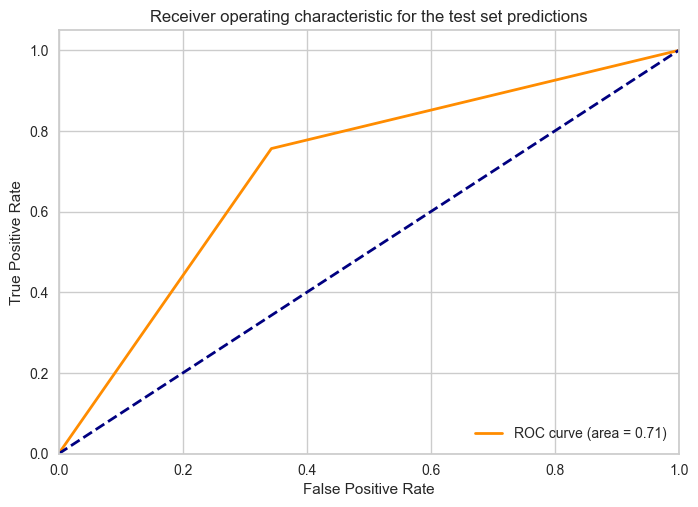

precision:  0.7088208469055375 recall:  0.7067448680351907 f1_score 0.7060142078764052


In [77]:
RF_A3_OR_PSD_Wind =  rf_cross_validation_with_cm(df_activity_windowed_psd_A3, test_set_size,pid = "None",tag=undersampling_method)

my_train_test_split() ================================ Clustering Centroids


/usr/local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Resampled Number of values in each class:  [(0, 884), (1, 884)]
my_train_test_split()/: X_train:  (1768, 40) y_train: (1768,) Value counts in train: <class 'pandas.core.series.Series'> type
0    884
1    884
Name: count, dtype: int64
my_train_test_split()/: X_test:  (354, 40) y_test:   (354,) Value counts in test: <class 'pandas.core.series.Series'> type
0    177
1    177
Name: count, dtype: int64
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1119
y_pred_probs: 
 [[0.67389924 0.32610076]
 [0.46858074 0.53141926]
 [0.28434101 0.71565899]
 [0.22892122 0.77107878]
 [0.33340056 0.66659944]
 [0.52282522 0.47717478]
 [0.22626837 0.77373163]
 [0.62877738 0.37122262]
 [0.24017338 0.75982662]
 [0.34469142 0.65530858]
 [0.56610831 0.43389169]
 [0.14375234 0.85624766]
 [0.49272724 0.50727276]
 [0.33357797 0.66642203]
 [0.21454686 0.78545314]
 [0.18634824 0.81365176]
 [0.5785306  0.4214694 ]
 [0.26352891 0.73647109]
 [0.40334445 0.59665555]
 [0.55430327 0.44569673]
 [0.59312476 0.40687524]
 [0.2210

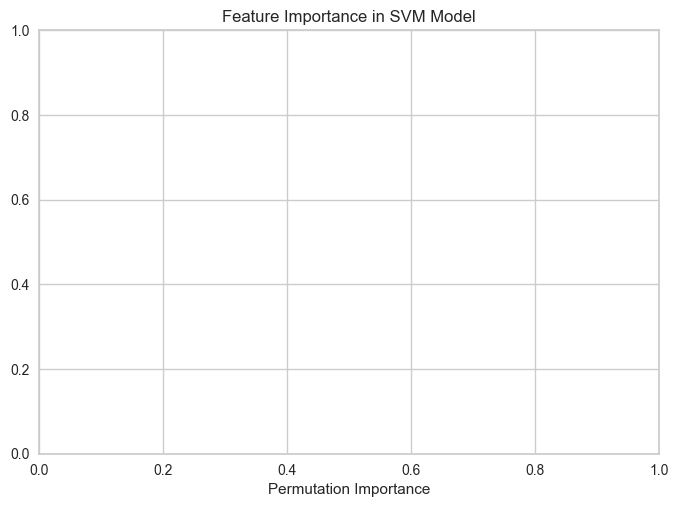

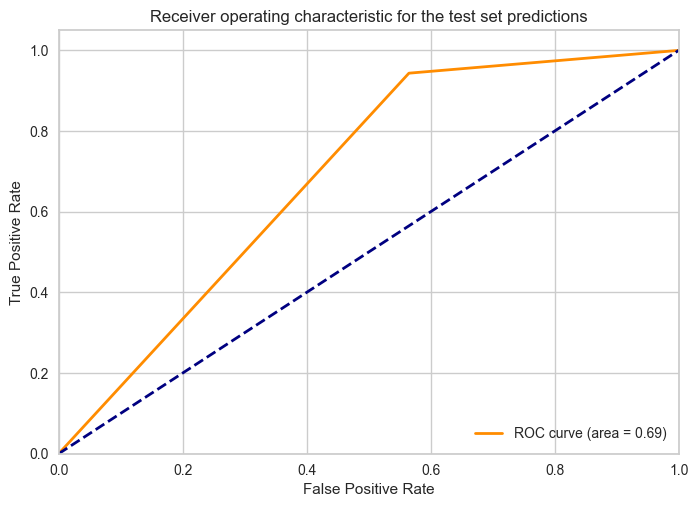

precision:  0.7552628180291876 recall:  0.6892655367231638 f1_score 0.6677927927927928
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1120
y_pred_probs: 
 [[0.72115476 0.27884524]
 [0.37085714 0.62914286]
 [0.26970238 0.73029762]
 [0.23795238 0.76204762]
 [0.42275794 0.57724206]
 [0.59217857 0.40782143]
 [0.18783333 0.81216667]
 [0.65030556 0.34969444]
 [0.20815079 0.79184921]
 [0.40916667 0.59083333]
 [0.4654881  0.5345119 ]
 [0.15459524 0.84540476]
 [0.53116667 0.46883333]
 [0.26197619 0.73802381]
 [0.213      0.787     ]
 [0.17878571 0.82121429]
 [0.64733442 0.35266558]
 [0.24896429 0.75103571]
 [0.4052619  0.5947381 ]
 [0.5965119  0.4034881 ]
 [0.57493651 0.42506349]
 [0.20877778 0.79122222]
 [0.30358333 0.69641667]
 [0.15902381 0.84097619]
 [0.42990476 0.57009524]
 [0.32875    0.67125   ]
 [0.14633333 0.85366667]
 [0.17906746 0.82093254]
 [0.28595238 0.71404762]
 [0.35708333 0.64291667]
 [0.51741667 0.48258333]
 [0.1275     0.8725    ]
 [0.4674881  0.5325119 ]
 [0.38439683 0.6156031

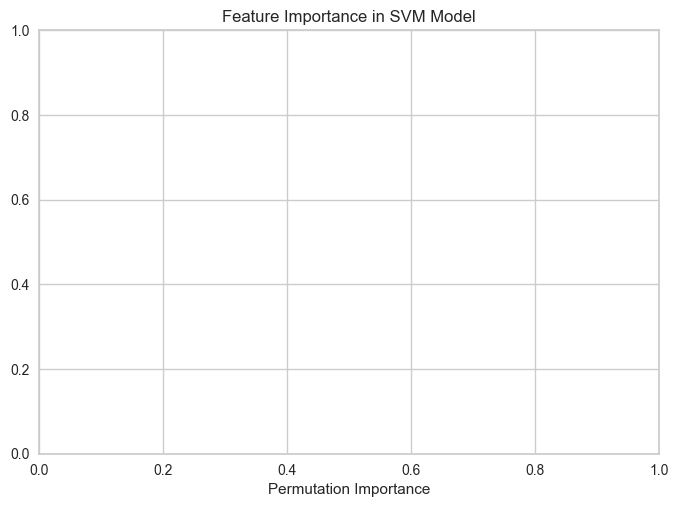

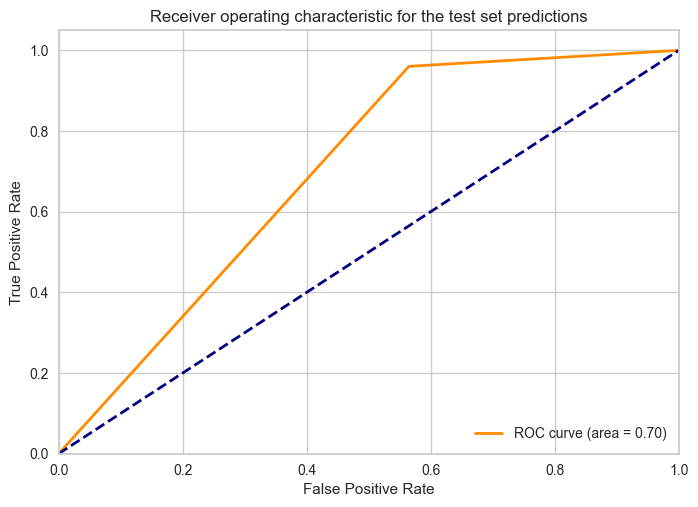

precision:  0.7731481481481481 recall:  0.6977401129943502 f1_score 0.675332356193268


In [78]:
RF_A4_OR_PSD_Wind =  rf_cross_validation_with_cm(df_activity_windowed_psd_A4, test_set_size,pid = "None",tag=undersampling_method)

my_train_test_split() ================================ Clustering Centroids


/usr/local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Resampled Number of values in each class:  [(0, 5543), (1, 5543)]
my_train_test_split()/: X_train:  (11086, 40) y_train: (11086,) Value counts in train: <class 'pandas.core.series.Series'> type
0    5543
1    5543
Name: count, dtype: int64
my_train_test_split()/: X_test:  (2218, 40) y_test:   (2218,) Value counts in test: <class 'pandas.core.series.Series'> type
0    1109
1    1109
Name: count, dtype: int64
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1121
y_pred_probs: 
 [[0.60283333 0.39716667]
 [0.54583333 0.45416667]
 [0.38       0.62      ]
 ...
 [0.495      0.505     ]
 [0.57458333 0.42541667]
 [0.58391667 0.41608333]]
dataset pred probs: 
         Prob_0    Prob_1
0     0.602833  0.397167
1     0.545833  0.454167
2     0.380000  0.620000
3     0.497083  0.502917
4     0.297500  0.702500
...        ...       ...
2213  0.241667  0.758333
2214  0.261667  0.738333
2215  0.495000  0.505000
2216  0.574583  0.425417
2217  0.583917  0.416083

[2218 rows x 2 columns]
X_train_fold:  (5543

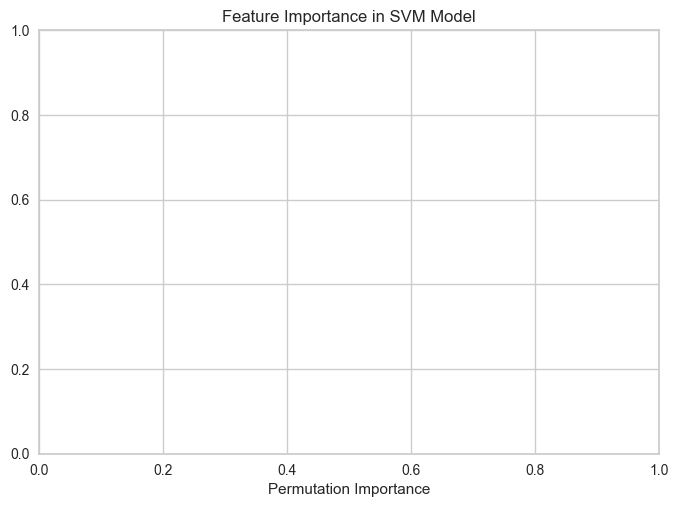

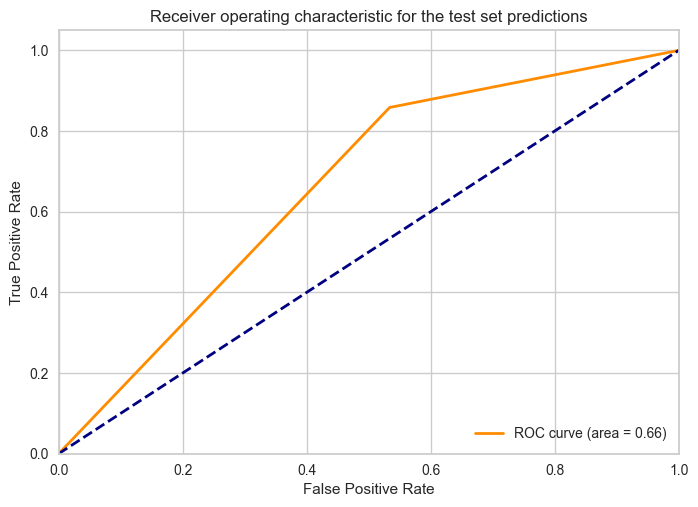

precision:  0.6918213127104441 recall:  0.6623083859332732 f1_score 0.6487997904572206
https://app.neptune.ai/shehjar/ADHD-SVM/e/AD-1122
y_pred_probs: 
 [[0.52595719 0.47404281]
 [0.52178499 0.47821501]
 [0.42659788 0.57340212]
 ...
 [0.39504762 0.60495238]
 [0.56452116 0.43547884]
 [0.49371898 0.50628102]]
dataset pred probs: 
         Prob_0    Prob_1
0     0.525957  0.474043
1     0.521785  0.478215
2     0.426598  0.573402
3     0.522288  0.477712
4     0.261664  0.738336
...        ...       ...
2213  0.248302  0.751698
2214  0.259048  0.740952
2215  0.395048  0.604952
2216  0.564521  0.435479
2217  0.493719  0.506281

[2218 rows x 2 columns]
X_train_fold:  (7390, 40) y_train_fold:  (7390,)
TP:  1418 TN:  1594 FP:  254 FN:  430
sensitivity:  0.7673160173160173 specificity:  0.8625541125541125
X_train_fold:  (7391, 40) y_train_fold:  (7391,)
TP:  1486 TN:  1581 FP:  267 FN:  361
sensitivity:  0.8045479155387114 specificity:  0.8555194805194806
X_train_fold:  (7391, 40) y_train_fold

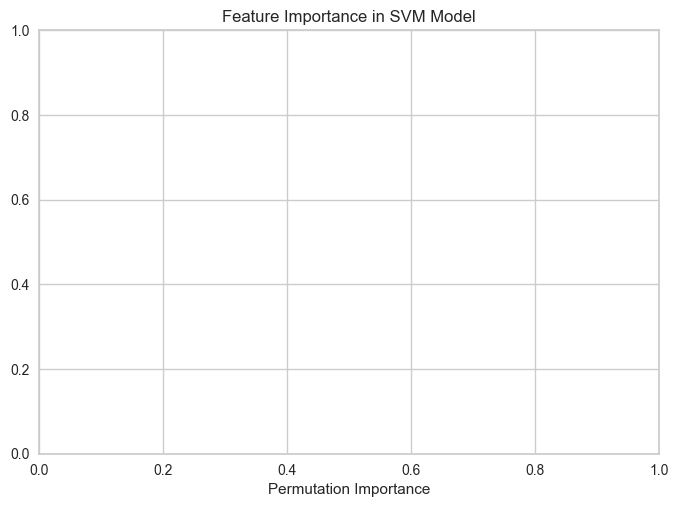

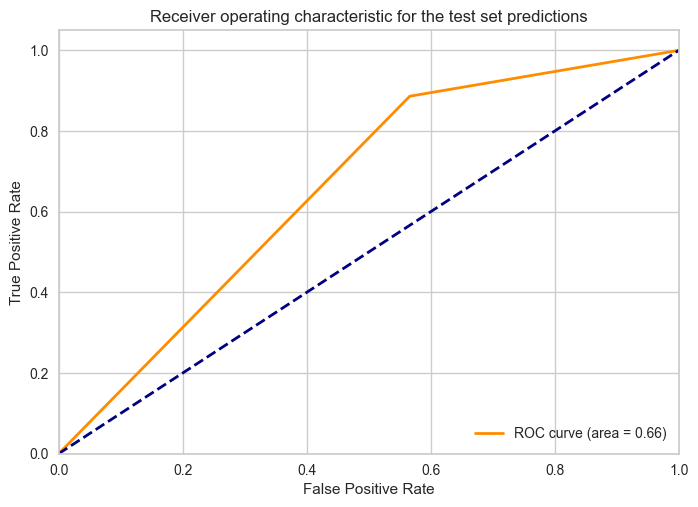

precision:  0.7013008793539474 recall:  0.6600541027953111 f1_score 0.6417000891265597


In [79]:
RF_psd_all =  rf_cross_validation_with_cm(df_activity_windowed_psd_all_act,test_set_size,pid = "None",tag=undersampling_method)


# Participant wise validation


In [ ]:
################## Participant based validation: ##################
for i in df_activity_windowed_psd_all_act["participantId"].unique():
    val_count = df_activity_windowed_psd_all_act[df_activity_windowed_psd_all_act["participantId"]== i]["type"].value_counts()
    print("Participant ID ====",i ,val_count.to_dict())
    if 1 in val_count.to_dict():
        if val_count.to_dict()[1]> 12:
            print("val_count: ",val_count)
            rf_cross_validation_with_cm(df_activity_windowed_psd_all_act[df_activity_windowed_psd_all_act["participantId"]== i],test_set_size,i,tag="Clus")
            